In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('Social_Network_Ads.csv')

In [16]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
294,15566689,Female,35,57000,0
149,15767871,Male,20,74000,0
245,15722061,Female,51,146000,1
70,15756932,Male,25,80000,0
153,15619087,Female,36,50000,0


As we can see that the dataset consists of id, categorical and Numerical data. To apply scaling, we can only apply it for numerical data. 

In [17]:
df = df.iloc[:,2:]

In [18]:
df.sample(5)

,Age,EstimatedSalary,Purchased
158,26,30000,0
148,29,61000,0
372,39,73000,0
209,46,22000,0
155,31,15000,0


#### Note: It is best practice to do feature engineering like handling categorical, scalling after the train test split

## Train test split

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(df.drop('Purchased',axis=1),
                                                    df['Purchased'],
                                                    random_state=41,
                                                    test_size=0.2)
X_train.shape, X_test.shape

((320, 2), (80, 2))

In [49]:
X_train.describe()

,Age,EstimatedSalary
count,320.000000,320.000000
mean,37.678125,69684.375000
std,10.291952,34521.408644
min,18.000000,15000.000000
25%,29.750000,43000.000000
50%,37.000000,68000.000000
75%,45.250000,87000.000000
max,60.000000,150000.000000


In [50]:
X_test.describe()

,Age,EstimatedSalary
count,80.000000,80.000000
mean,37.562500,69975.000000
std,11.282162,32552.187894
min,18.000000,15000.000000
25%,29.750000,48500.000000
50%,36.500000,71500.000000
75%,47.000000,88250.000000
max,60.000000,144000.000000


## Standard scaler

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled=scaler.transform(X_test)

In [52]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [53]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,-0.0
75%,0.7,0.5
max,2.2,2.3


In [54]:
np.round(X_test_scaled.describe(),1)

,Age,EstimatedSalary
count,80.0,80.0
mean,-0.0,0.0
std,1.1,0.9
min,-1.9,-1.6
25%,-0.8,-0.6
50%,-0.1,0.1
75%,0.9,0.5
max,2.2,2.2


As we see that the scaled data's mean and st deviation is close to 0 and 1 respectively.

In [55]:
X_train_scaled.sample(5)

,Age,EstimatedSalary
207,0.225954,-0.658140
106,-0.260623,-1.296423
215,-1.623040,-1.557539
145,-0.260623,0.531389
235,0.323270,0.067183


In [56]:
X_test_scaled.sample(5)

,Age,EstimatedSalary
61,0.323270,-0.280972
62,1.004478,-1.151359
13,-0.260623,1.111647
7,1.296425,1.865983
18,0.907163,1.256712


### Effect of scalling

Let us see the effect of scalling in terms of distribution

Text(0.5, 1.0, 'After scaling')

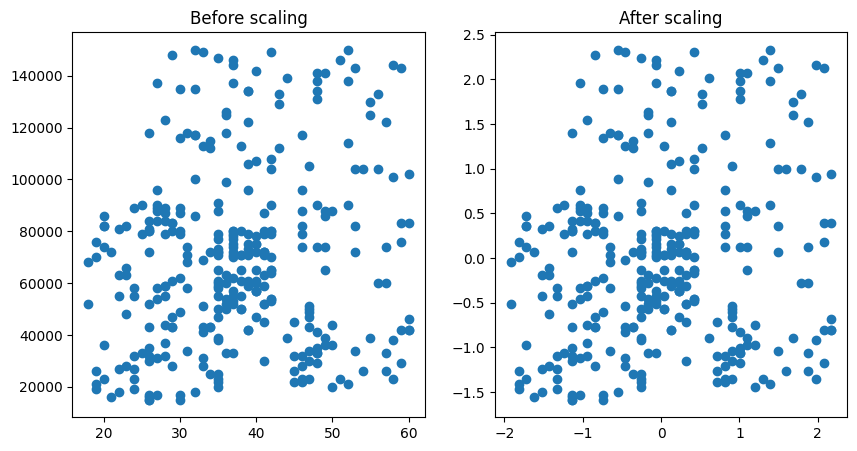

In [57]:
_, (ax1,ax2) = plt.subplots(ncols=2,figsize = (10,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'])
ax1.set_title('Before scaling')
ax2.set_title('After scaling')

#### scatter plot is same becoz the numbers are scaled down to lower numbers ie no change in distribution

Text(0.5, 1.0, 'After scaling')

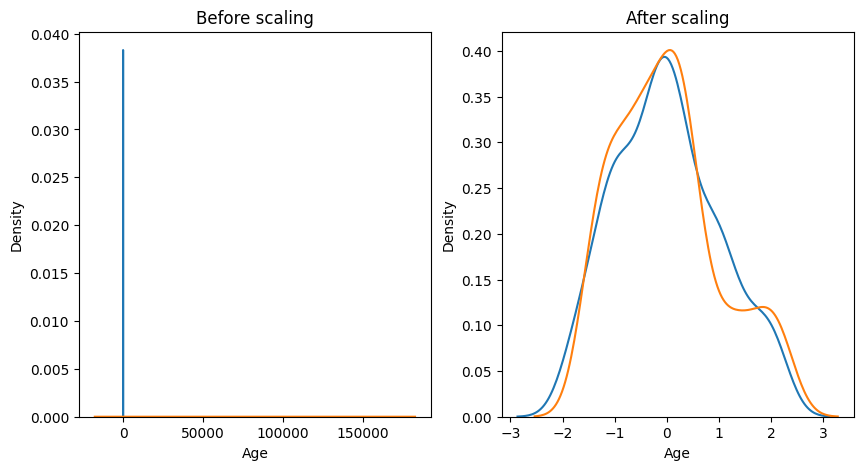

In [58]:
_, (ax1,ax2) = plt.subplots(ncols=2,figsize = (10,5))
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
ax1.set_title('Before scaling')
ax2.set_title('After scaling')

#### plots are not comparable before scaling becoz age in 10's and salary is in 10000's. But after scaling both comes into same scale

## Note: Scaling is needed only for algos that depends on distance. Like logistic, knn. Scaling doesnt needed for algos like Xgboost, random forest, decision tree

### Why scaling imp?

In [59]:
from sklearn.linear_model import LogisticRegression

In [60]:
lr=LogisticRegression()
lr.fit(X_train,Y_train)

LogisticRegression()

In [61]:
lr_s = LogisticRegression()
lr_s.fit(X_train_scaled,Y_train)

LogisticRegression()

In [62]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_s.predict(X_test_scaled)

In [63]:
from sklearn.metrics import accuracy_score

In [64]:
print(f"Before scaling accuracy:{accuracy_score(Y_test,y_pred)}")
print(f"After scaling accuracy:{accuracy_score(Y_test,y_pred_scaled)}")

Before scaling accuracy:0.775
After scaling accuracy:0.7875


As we see the accuracy is increased slightly. Logistic reg can handle the data which is not having so much difference in terms of scale. As we see the diff in scale is not so large. So it doesnt giving so much diff in terms of accuracy. But it makes sure that the model performs fastly with less computation

In [65]:
from sklearn.tree import DecisionTreeClassifier

In [68]:
d = DecisionTreeClassifier()
d.fit(X_train,Y_train)

DecisionTreeClassifier()

In [69]:
d_s = DecisionTreeClassifier()
d_s.fit(X_train_scaled,Y_train)

DecisionTreeClassifier()

In [70]:
y_pred=d.predict(X_test)
y_pred_scaled=d_s.predict(X_test_scaled)

In [71]:
print(f"Before scaling accuracy:{accuracy_score(Y_test,y_pred)}")
print(f"After scaling accuracy:{accuracy_score(Y_test,y_pred_scaled)}")

Before scaling accuracy:0.8625
After scaling accuracy:0.8375


As we seen that the tree like models which are depends on decison making rather that distance based approach doesnt have any effect with scaling